In [28]:
using NCDatasets, Plots, Statistics, Dates

In [29]:
# load dataset
ds = NCDataset("../gulf_stream_oct25_to_dec25.nc")

# Get variables
times = ds["time"][:];
lat = ds["latitude"][:];
lon = ds["longitude"][:];

# Get velocity components
u_vel = ds["uo"][:, :, :, :];
v_vel = ds["vo"][:, :, :, :];

In [30]:
speed_anim = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax))
end

mp4(speed_anim, "ocean_currents_speed.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\quick_traverse_test\ocean_currents_speed.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\quick_traverse_test\\ocean_currents_speed.mp4")

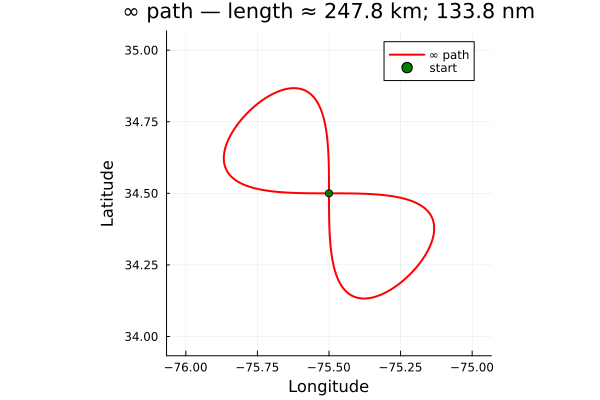

In [31]:
# thinner infinity-shaped path centered at (-75.5, 34.5)
t = range(0, 2π, length=400)
amp_lon = 0.4
amp_lat = 0.2
cx, cy = -75.5, 34.5

lon0 = cx .+ amp_lon .* sin.(t)
lat0 = cy .+ amp_lat .* sin.(2 .* t)

# rotate by -45 degrees around center (convert degrees to radians)
θ = -45 * π / 180
dx = lon0 .- cx
dy = lat0 .- cy
lon_path = cx .+ (dx .* cos(θ) .- dy .* sin(θ))
lat_path = cy .+ (dx .* sin(θ) .+ dy .* cos(θ))

path = collect(zip(lon_path, lat_path))

# haversine distance (meters) and conversions
R = 6_371_000.0
deg2rad(x) = x * π / 180

haversine(lon1, lat1, lon2, lat2) = begin
    dlat = deg2rad(lat2 - lat1)
    dlon = deg2rad(lon2 - lon1)
    a = sin(dlat/2)^2 + cos(deg2rad(lat1)) * cos(deg2rad(lat2)) * sin(dlon/2)^2
    2 * R * atan(sqrt(a), sqrt(1 - a)) # meters
end

# conversion helpers
m2km(m) = m / 1000.0
m2nm(m) = m / 1852.0  # nautical miles

# helper to compute path lengths in m, km, nm
function path_lengths(lons, lats)
    n = length(lons)
    total_m = sum(haversine(lons[i], lats[i], lons[(i % n) + 1], lats[(i % n) + 1]) for i in 1:n)
    (total_m, m2km(total_m), m2nm(total_m))
end

n = length(lon_path)
total_length_m = sum(haversine(lon_path[i], lat_path[i], lon_path[(i % n) + 1], lat_path[(i % n) + 1]) for i in 1:n)

# quick plot with length in title
plot(lon_path, lat_path;
    lw=2, lc=:red, label="∞ path",
    title = "∞ path — length ≈ $(round(m2km(total_length_m); digits=1)) km; $(round(m2nm(total_length_m); digits=1)) nm",
    xlabel="Longitude", ylabel="Latitude",
    xlims=(minimum(lon_path)-0.2, maximum(lon_path)+0.2),
    ylims=(minimum(lat_path)-0.2, maximum(lat_path)+0.2),
    aspect_ratio=:equal)
scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")

In [32]:
# recompute segment lengths
n = length(lon_path)
seg_lengths = [haversine(lon_path[i], lat_path[i], lon_path[(i % n) + 1], lat_path[(i % n) + 1]) for i in 1:n]
total_length_m = sum(seg_lengths)
cumlen = cumsum(seg_lengths)

# helper to convert Period to seconds
period_seconds(p::Dates.Period) = p isa Dates.Millisecond ? Dates.value(p)/1000.0 :
                                 p isa Dates.Second      ? Dates.value(p) :
                                 p isa Dates.Minute      ? Dates.value(p)*60.0 :
                                 p isa Dates.Hour        ? Dates.value(p)*3600.0 :
                                 p isa Dates.Day         ? Dates.value(p)*86400.0 :
                                 Dates.value(p)/1000.0

# sampling every 30 minutes
sample_interval_sec = 30 * 60.0

# determine sample times (and seconds since start)
if length(times) > 1 && isa(times[1], DateTime)
    sample_times = collect(times[1]:Minute(30):times[end])
    t_seconds = [period_seconds(t - sample_times[1]) for t in sample_times]
else
    # assume numeric times where differences are in seconds (fall back to original span)
    t0 = times[1]
    tend = times[end]
    total_sim_time = float(tend - t0)
    t_seconds = collect(0.0:sample_interval_sec:total_sim_time)
    sample_times = [t0 + s for s in t_seconds]
end

# distances along loop for each sample time
distances = speed .* t_seconds

# interpolate lon/lat along loop for each distance (wrap-around)
boat_pos = Vector{Tuple{Float64,Float64}}(undef, length(distances))
for (k, d) in enumerate(distances)
    if total_length_m == 0.0
        boat_pos[k] = (lon_path[1], lat_path[1])
        continue
    end
    dmod = mod(d, total_length_m)
    # if exactly 0 use last point as wrap-around (treat as start)
    idx = searchsortedfirst(cumlen, dmod == 0.0 ? 1e-12 : dmod)
    idx = clamp(idx, 1, n)
    prev = idx == 1 ? 0.0 : cumlen[idx-1]
    seglen = seg_lengths[idx]
    frac = seglen == 0 ? 0.0 : clamp((dmod - prev) / seglen, 0.0, 1.0)
    jnext = (idx % n) + 1
    lonp = lon_path[idx] + frac * (lon_path[jnext] - lon_path[idx])
    latp = lat_path[idx] + frac * (lat_path[jnext] - lat_path[idx])
    boat_pos[k] = (lonp, latp)
end

# override times so downstream cells use the 30-min sampled times
times = sample_times

# report
total_time = total_length_m / speed
h_loop = floor(Int, total_time) ÷ 3600
m_loop = floor(Int, total_time) % 3600 ÷ 60
s_loop = total_time - h_loop*3600 - m_loop*60
dataset_seconds = t_seconds[end]
println("Loop length = $(round(total_length_m; digits=1)) m")
println("Loop time = $(round(total_time; digits=1)) s  ($(h_loop)h $(m_loop)m $(round(s_loop; digits=1))s) per loop")
println("Dataset duration = $(round(dataset_seconds; digits=1)) s; samples = $(length(distances)) (every 30 min)")
println("Simulated loops ≈ $(round(dataset_seconds/total_time; digits=2)) (wrap-around enabled)")


Loop length = 247751.6 m
Loop time = 99100.7 s  (27h 31m 40.7s) per loop
Dataset duration = 5.2704e6 s; samples = 2929 (every 30 min)
Simulated loops ≈ 53.18 (wrap-around enabled)


In [36]:
anim = @animate for k in 1:10:length(distances)
    lonp, latp = boat_pos[k]
    t_sample = times[k]

    ds_times = ds["time"][:]
    idx1 = searchsortedfirst(ds_times, t_sample)
    if idx1 == 1
        i0 = i1 = 1
    elseif idx1 > length(ds_times)
        i0 = i1 = length(ds_times)
    else
        i1 = idx1
        i0 = idx1 - 1
    end

    if i0 == i1
        u_frame = u_vel[:, :, 1, i0]
        v_frame = v_vel[:, :, 1, i0]
    else
        t0 = ds_times[i0]; t1 = ds_times[i1]
        if isa(ds_times[1], DateTime)
            denom = period_seconds(t1 - t0)
            α = denom == 0 ? 0.0 : period_seconds(t_sample - t0) / denom
        else
            denom = float(t1 - t0)
            α = denom == 0 ? 0.0 : float(t_sample - t0) / denom
        end
        u_frame = (1-α) .* u_vel[:, :, 1, i0] .+ α .* u_vel[:, :, 1, i1]
        v_frame = (1-α) .* v_vel[:, :, 1, i0] .+ α .* v_vel[:, :, 1, i1]
    end

    speed_field = sqrt.(u_frame.^2 .+ v_frame.^2)'
    contourf(lon, lat, speed_field;
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    plot!(lon_path, lat_path;
        lw=2, lc=:blue, label="∞ path",
        xlims=(minimum(lon_path)-0.2, maximum(lon_path)+0.2),
        ylims=(minimum(lat_path)-0.2, maximum(lat_path)+0.2),
        aspect_ratio=:equal, legend=:topright)
    scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")
    scatter!([lonp], [latp]; color=:red, markersize=6, label="boat")
    title!("Boat — t=$(times[k])")
    xlabel!("Longitude"); ylabel!("Latitude")
    plot!(clims=(0.0, 3.0))
end

mp4(anim, "boat_along_path_time_order.mp4", fps=15)


┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\quick_traverse_test\boat_along_path_time_order.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\quick_traverse_test\\boat_along_path_time_order.mp4")